In [5]:
!pip install planet
!pip install rasterio
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 67.0 MB/s eta 0:00:00


In [6]:
import os
import json
import planet
import pathlib
import asyncio
import requests
from requests.auth import HTTPBasicAuth

import rasterio
from rasterio.plot import show
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm

import matplotlib.pyplot as plt

In [ ]:
PLANET_API_KEY = "" #insert your Planet API key here
auth = HTTPBasicAuth(PLANET_API_KEY, '')

In [27]:
# Read a geojson file as a list of geometries
def parse_geojson(filename):
    geoms = []
    features = json.load(open(filename))
    if "type" in features and features["type"] == "FeatureCollection":
        for f in features["features"]:
            geoms.append(f["geometry"])
    elif "type" in features and features["type"] == "Feature":
         geoms.append(features["geometry"])
    else:
        geoms = [features]

    return geoms

In [28]:
def check_quads(geom, basemap):

    # Set the base URL for the Planet Basemaps API
    BASE_URL = 'https://api.planet.com/basemaps/v1/mosaics/'

    # First, get the basemap ID (you need to know which basemap you're searching)

    res = requests.get(url=BASE_URL, auth=auth, params={'name__is': basemap}).json()
    BASEMAP_ID = res['mosaics'][0]['id']

    # Now, search for quads
    quads_url = BASE_URL + BASEMAP_ID + '/quads/search'
    quads_res = requests.post(url=quads_url, auth=auth, json=geom).json()

    # The "items" list in the response contains the list of intersected quads
    quads = quads_res['items']

    print(f"Found {len(quads)} quads that intersect with the AOI.")

    # Handle pagination if there are many results
    while '_next' in quads_res.get('_links', {}):
        next_url = quads_res['_links']['_next']
        quads_res = requests.get(url=next_url, auth=auth).json()
        quads.extend(quads_res['items'])
        print(f"Total quads found: {len(quads)}")
    return len(quads)

In [29]:
def create_request(aoi,plot,basemap):
    order_params = {
        "name": plot,
        "source_type": "basemaps",
        "order_type": "partial",
        "products": [
            {
                "mosaic_name": basemap,
                "geometry": aoi
            }
        ],
        "tools": [
            {"merge": {}},
            {"clip": {}},
            {"bandmath": {
                "b1": "b1",
                "b2": "b2",
                "b3": "b3",
                "b4": 'b4',
                "b5": "1 / ((0.1 - b3)**2+(0.06-b4)**2)*1000",
                "pixel_type": "32R"
                }
            }
        ]
    }

    return order_params

In [30]:
async def create_orders(client,order,directory):
    directory = directory+'/'+order['name']+'/'+order['products'][0]['mosaic_name']

    order = await client.create_order(order)

    return {order['id']: directory}

In [46]:
def download_orders(order_path):
    # Setup the session
    session = requests.Session()
    # Authenticate
    session.auth = (PLANET_API_KEY, "")
    #load the orders
    orders = json.load(open(order_path))
    done_ids = []
    for order_id in orders:
        order_url = 'https://api.planet.com/compute/ops/orders/v2/' + order_id
        r = requests.get(order_url, auth=session.auth)

        if r.json()['state'] == 'success':
            results = r.json()['_links']['results']
            results_urls = [r['location'] for r in results]
            results_names = [r['name'] for r in results]

            for url, name in zip(results_urls, results_names):
                path = pathlib.Path(os.path.join( orders[order_id], name.split('/')[-1]))

                if not path.exists():
                    #print('downloading {} to {}'.format(name, path))
                    r = requests.get(url, allow_redirects=True)
                    path.parent.mkdir(parents=True, exist_ok=True)
                    open(path, 'wb').write(r.content)
                else:
                    print('{} already exists, skipping'.format(path))
            done_ids.append(order_id)
            print(str(len(done_ids)) + '/' + str(len(orders)))
            # Remove the order from the list after download is complete
        else:
            print(r.json())
            print(r.json()['last_message'])
            print(f"Order {order_id} is not yet complete, skipping")

    for order_id in done_ids:
        del orders[order_id]
    print(f"{len(orders)} orders remaining")
    # Save the updated orders back to the file
    with open(order_path, 'w') as f:
        json.dump(orders, f, indent=4)

In [32]:
folder_name = "."
aoi = "/content/fire_demo.geojson"
basemap = "ps_monthly_sen2_normalized_analytic_subscription_2025_03_mosaic"
order_request = []
geoms = parse_geojson(aoi)

In [33]:
i = 0
for geom in geoms:
    # Check if the geometry intersects with the basemap
    num_quads = check_quads(geom, basemap)
    if num_quads > 0:
        name = "order_" + str(i)
        i += 1
        order_request.append(create_request(geom,name, basemap))

Found 4 quads that intersect with the AOI.


In [34]:
pl_auth = planet.Auth.from_key(PLANET_API_KEY)
pl_auth.store()


In [35]:
print( f"{len(order_request)} orders to go")
print(order_request[0])
orders = {}
async with planet.Session() as sess:
    client = sess.client('orders')
    new_orders = await asyncio.gather(*[create_orders(client, order, folder_name) for order in order_request])

    for order in new_orders:
        orders.update(order)

    with open(os.path.join(folder_name, 'orders.json'), 'w') as f:
        json.dump(orders, f, indent=4)


1 orders to go
{'name': 'order_0', 'source_type': 'basemaps', 'order_type': 'partial', 'products': [{'mosaic_name': 'ps_monthly_sen2_normalized_analytic_subscription_2025_03_mosaic', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[-107.69482241273332, 28.189079780239464], [-107.56821735641185, 28.190611381262094], [-107.5659831495356, 28.06166141425794], [-107.69482241273332, 28.06056609888562], [-107.69482241273332, 28.189079780239464]]]]}}], 'tools': [{'merge': {}}, {'clip': {}}, {'bandmath': {'b1': 'b1', 'b2': 'b2', 'b3': 'b3', 'b4': 'b4', 'b5': '1 / ((0.1 - b3)**2+(0.06-b4)**2)*1000', 'pixel_type': '32R'}}]}


In [47]:
download_orders("./orders.json")

1/1
0 orders remaining


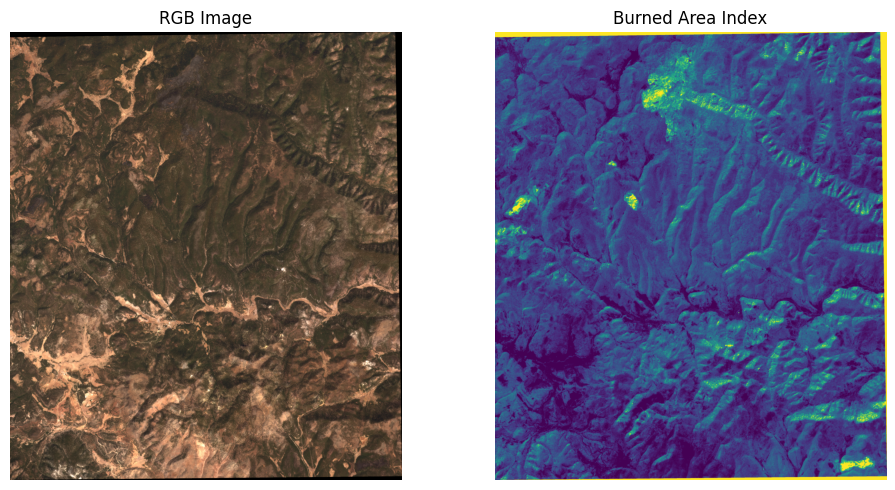

In [49]:
def display_geotiff(path):
    with rasterio.open(path) as src:
        # Read the first three bands for RGB
        blue = src.read(1)
        green = src.read(2)
        red = src.read(3)

        # Stack the bands into an RGB image
        rgb = np.stack((red, green, blue), axis=-1)

        # Normalize the RGB image for display
        rgb_normalized = (rgb - rgb.min()) / (rgb.max() - rgb.min())

        # Apply a brightness scaling factor
        brightness_factor = 4  # Increase brightness by 50%
        rgb_brightened = np.clip(rgb_normalized * brightness_factor, 0, 1)

        # Read the 5th band
        band5 = src.read(5)

        # Apply a custom contrast stretch
        p2, p98 = np.percentile(band5, (2, 98))
        band5_stretched = np.clip((band5 - p2) / (p98 - p2), 0, 1)

        # Display the RGB image
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(rgb_brightened)
        plt.title("RGB Image")
        plt.axis("off")

        # Display the 5th band with viridis colormap
        plt.subplot(1, 2, 2)
        plt.imshow(band5_stretched, cmap="viridis", norm=Normalize(vmin=0, vmax=1))
        plt.title("Burned Area Index")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# Example usage
display_geotiff("/content/order_0/ps_monthly_sen2_normalized_analytic_subscription_2025_03_mosaic/ps_monthly_sen2_normalized_analytic_subscription_2025_03_mosaic_merge_clip_bandmath.tif")


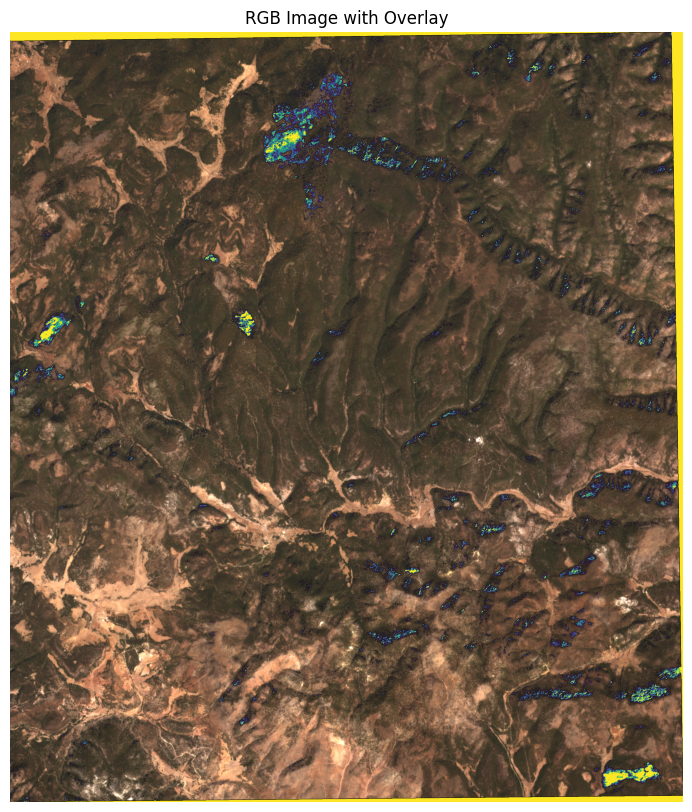

In [51]:
def plot_geotiff_with_overlay(path):
    with rasterio.open(path) as src:
        # Read the first three bands for RGB
        blue = src.read(1)
        green = src.read(2)
        red = src.read(3)

        # Stack the bands into an RGB image
        rgb = np.stack((red, green, blue), axis=-1)

        # Normalize the RGB image for display
        rgb_normalized = (rgb - rgb.min()) / (rgb.max() - rgb.min())
                # Apply a brightness scaling factor
        brightness_factor = 4  # Increase brightness by 50%
        rgb_brightened = np.clip(rgb_normalized * brightness_factor, 0, 1)

        # Read the 5th band
        band5 = src.read(5)

        # Calculate the 95th percentile threshold
        threshold = np.percentile(band5, 95.5)

        # Keep values above the 95th percentile, set others to 0
        overlay_mask = np.where(band5 >= threshold, band5, 0)

                # Apply a custom contrast stretch
        p2, p98 = np.percentile(overlay_mask, (2, 98))
        overlay_mask_stretched = np.clip((overlay_mask - p2) / (p98 - p2), 0, 1)



        # Plot the RGB image
        plt.figure(figsize=(10, 10))
        plt.imshow(rgb_brightened)
        plt.title("RGB Image with Overlay")
        plt.axis("off")



        # Make all 0 values transparent
        overlay_mask_alpha = np.ma.masked_where(overlay_mask == 0, overlay_mask_stretched)
        plt.imshow(overlay_mask_alpha, cmap="viridis", alpha=1)

        plt.show()

# Example usage
plot_geotiff_with_overlay("/content/order_0/ps_monthly_sen2_normalized_analytic_subscription_2025_03_mosaic/ps_monthly_sen2_normalized_analytic_subscription_2025_03_mosaic_merge_clip_bandmath.tif")